In [2]:
# ==========================================
# Fix Module Import Path for Notebook
# ==========================================

import sys
import os

# Get project root (one level above notebooks/)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

Project root added to sys.path: e:\Job-Related-Repos\jee-2026-shiftwise-performance-analysis


🧩 📌 Cell 1 — Imports & Setup

In [3]:
# ==========================================
# Imports & Logging Setup
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.logger import get_logger
from src.data_loader import load_percentile_data, load_question_data
from src.analysis import calculate_shift_averages, rank_shift_difficulty

sns.set(style="whitegrid")

logger = get_logger("EDA_Notebook")

DATA_DIR = "../data"

logger.info("Notebook environment initialized.")

2026-02-28 23:35:25 | INFO | 3252587678.py::<module> | Notebook environment initialized.


📥 📌 Cell 2 — Load Data

In [4]:
# ==========================================
# Load Data
# ==========================================

logger.info("Loading percentile datasets.")
percentile_data = load_percentile_data(DATA_DIR)

logger.info("Loading question dataset.")
question_data = load_question_data(DATA_DIR)

logger.info("Data loaded successfully.")

2026-02-28 23:35:52 | INFO | 817163345.py::<module> | Loading percentile datasets.
2026-02-28 23:35:52 | INFO | data_loader.py::load_percentile_data | Starting to load percentile data.
2026-02-28 23:35:52 | INFO | data_loader.py::load_percentile_data | Loading Overall data from ..\data\JEE-Mains-2026-Jan-Percentile-Summary.csv
2026-02-28 23:35:52 | INFO | data_loader.py::load_percentile_data | Overall processed successfully. Final shape: (230, 4)
2026-02-28 23:35:52 | INFO | data_loader.py::load_percentile_data | Loading Maths data from ..\data\JEE-Mains-2026-Jan-Maths-Percentile-Summary.csv
2026-02-28 23:35:52 | INFO | data_loader.py::load_percentile_data | Maths processed successfully. Final shape: (140, 4)
2026-02-28 23:35:52 | INFO | data_loader.py::load_percentile_data | Loading Physics data from ..\data\JEE-Mains-2026-Jan-Physics-Percentile-Summary.csv
2026-02-28 23:35:52 | INFO | data_loader.py::load_percentile_data | Physics processed successfully. Final shape: (140, 4)
2026-02

📊 📌 Cell 3 — Shift-wise Averages

In [5]:
# ==========================================
# Shift-wise Subject Averages
# ==========================================

logger.info("Calculating shift-wise averages.")

shift_avg_df = calculate_shift_averages(percentile_data)
rank_df = rank_shift_difficulty(shift_avg_df)

display(shift_avg_df)
display(rank_df)

2026-02-28 23:36:05 | INFO | 3249565242.py::<module> | Calculating shift-wise averages.
2026-02-28 23:36:05 | INFO | analysis.py::calculate_shift_averages | Calculating shift-wise subject averages.
2026-02-28 23:36:05 | INFO | analysis.py::calculate_shift_averages | Shift averages calculated successfully.
2026-02-28 23:36:05 | INFO | analysis.py::rank_shift_difficulty | Ranking shifts by difficulty.
2026-02-28 23:36:05 | INFO | analysis.py::rank_shift_difficulty | Shift difficulty ranking completed.


,Maths,Physics,Chemistry
Shift,,,
21 Jan-Shift1,32.428571,52.500000,49.071429
21 Jan-Shift2,28.500000,56.071429,49.285714
22 Jan-Shift1,29.000000,54.214286,39.500000
22 Jan-Shift2,26.214286,57.857143,41.214286
23 Jan-Shift1,28.357143,55.642857,41.571429
23 Jan-Shift2,28.071429,50.785714,48.857143
24 Jan-Shift1,24.214286,51.428571,53.615385
24 Jan-Shift2,29.285714,52.571429,41.785714
28 Jan-Shift1,26.500000,54.928571,47.500000


,Total_Avg,Difficulty_Rank
Shift,,
21 Jan-Shift1,134.000000,10
21 Jan-Shift2,133.857143,9
22 Jan-Shift1,122.714286,1
22 Jan-Shift2,125.285714,3
23 Jan-Shift1,125.571429,4
23 Jan-Shift2,127.714286,5
24 Jan-Shift1,129.258242,7
24 Jan-Shift2,123.642857,2
28 Jan-Shift1,128.928571,6


🏷 📌 Cell 4 — Classify Shifts (Easy / Moderate / Tough / Toughest)

In [6]:
# ==========================================
# Shift Difficulty Classification
# ==========================================

logger.info("Classifying shifts based on Total Average marks.")

rank_df = rank_df.copy()

quantiles = rank_df["Total_Avg"].quantile([0.25, 0.5, 0.75])

def classify(avg):
    if avg <= quantiles[0.25]:
        return "Toughest"
    elif avg <= quantiles[0.5]:
        return "Tough"
    elif avg <= quantiles[0.75]:
        return "Moderate"
    else:
        return "Easy"

rank_df["Difficulty_Level"] = rank_df["Total_Avg"].apply(classify)

rank_df_sorted = rank_df.sort_values("Difficulty_Rank")

display(rank_df_sorted)

logger.info("Shift classification completed.")

2026-02-28 23:38:38 | INFO | 726391903.py::<module> | Classifying shifts based on Total Average marks.


,Total_Avg,Difficulty_Rank,Difficulty_Level
Shift,,,
22 Jan-Shift1,122.714286,1,Toughest
24 Jan-Shift2,123.642857,2,Toughest
22 Jan-Shift2,125.285714,3,Toughest
23 Jan-Shift1,125.571429,4,Tough
23 Jan-Shift2,127.714286,5,Tough
28 Jan-Shift1,128.928571,6,Moderate
24 Jan-Shift1,129.258242,7,Moderate
28 Jan-Shift2,129.642857,8,Easy
21 Jan-Shift2,133.857143,9,Easy


2026-02-28 23:38:38 | INFO | 726391903.py::<module> | Shift classification completed.


🎯 📌 Cell 5 — Subject-wise Toughest Shift

In [7]:
# ==========================================
# Subject-wise Toughest Shift
# ==========================================

logger.info("Finding subject-wise toughest shifts.")

toughest_subjectwise = {}

for subject in ["Maths", "Physics", "Chemistry"]:
    toughest_shift = shift_avg_df[subject].idxmin()
    toughest_subjectwise[subject] = toughest_shift

subject_tough_df = pd.DataFrame.from_dict(
    toughest_subjectwise,
    orient="index",
    columns=["Toughest_Shift"]
)

display(subject_tough_df)

2026-02-28 23:39:48 | INFO | 3740985431.py::<module> | Finding subject-wise toughest shifts.


,Toughest_Shift
Maths,24 Jan-Shift1
Physics,23 Jan-Shift2
Chemistry,22 Jan-Shift1


📉 📌 Cell 6 — Shift Volatility (Stability Analysis)

In [8]:
# ==========================================
# Shift Volatility Analysis
# ==========================================

logger.info("Calculating shift volatility.")

overall_df = percentile_data["Overall"]

volatility_df = (
    overall_df.groupby("Shift")["Marks"]
    .std()
    .sort_values(ascending=False)
    .to_frame(name="Std_Deviation")
)

display(volatility_df)

logger.info("Shift volatility analysis completed.")

2026-02-28 23:41:09 | INFO | 4252357598.py::<module> | Calculating shift volatility.


,Std_Deviation
Shift,
24 Jan-Shift2,46.441429
21 Jan-Shift2,44.716763
22 Jan-Shift1,44.120613
23 Jan-Shift2,43.649747
23 Jan-Shift1,42.653721
28 Jan-Shift1,42.088041
21 Jan-Shift1,42.001882
28 Jan-Shift2,41.680224
22 Jan-Shift2,41.057465


2026-02-28 23:41:09 | INFO | 4252357598.py::<module> | Shift volatility analysis completed.


📈 📌 Cell 7 — Visual Insights

1️⃣ Difficulty Classification Plot

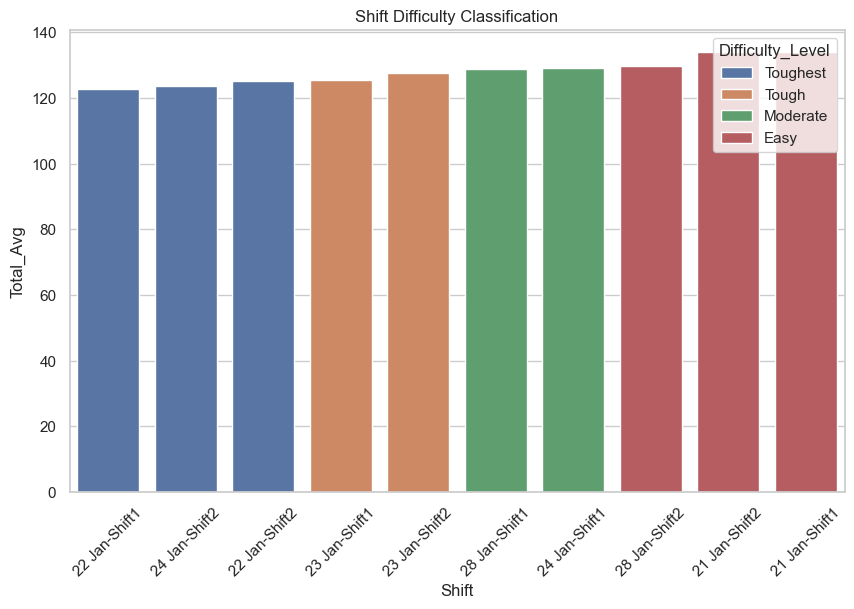

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=rank_df_sorted.index,
    y=rank_df_sorted["Total_Avg"],
    hue=rank_df_sorted["Difficulty_Level"]
)
plt.title("Shift Difficulty Classification")
plt.xticks(rotation=45)
plt.show()

2️⃣ Subject-wise Heatmap

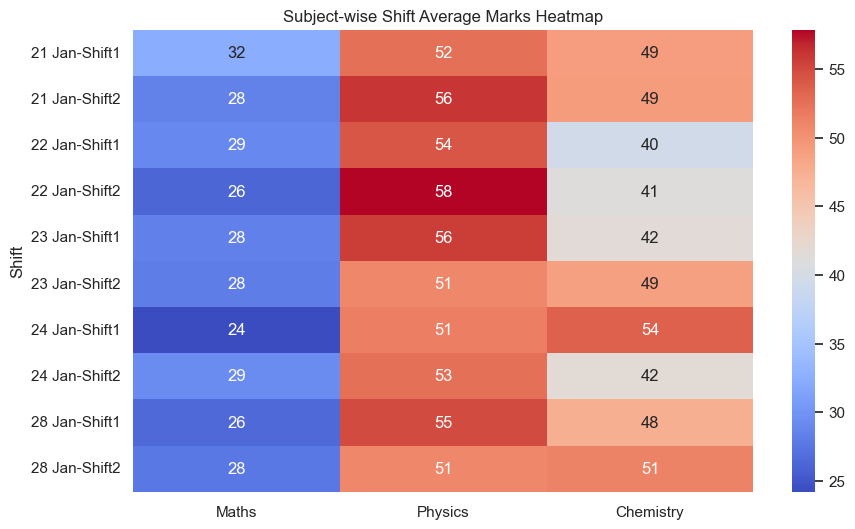

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(shift_avg_df, annot=True, cmap="coolwarm")
plt.title("Subject-wise Shift Average Marks Heatmap")
plt.show()

3️⃣ Volatility Plot

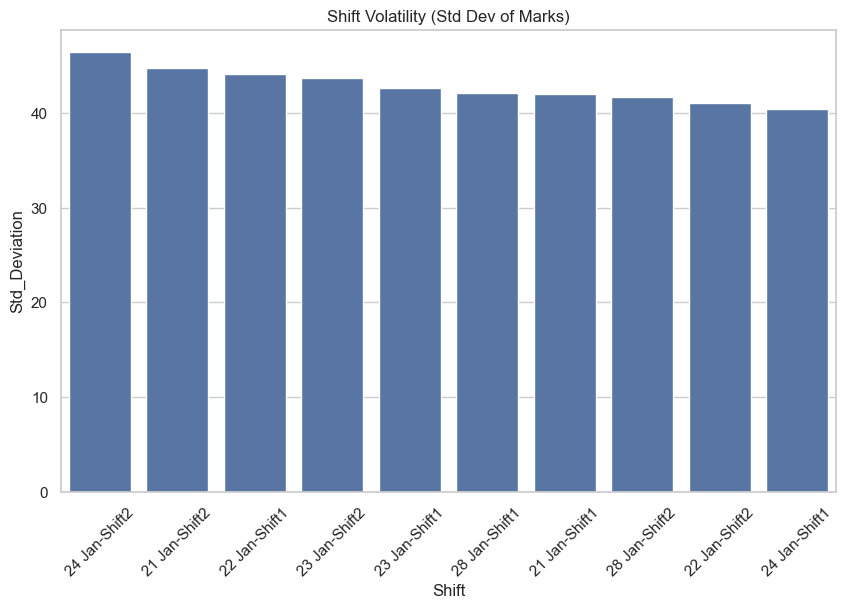

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=volatility_df.index,
    y=volatility_df["Std_Deviation"]
)
plt.title("Shift Volatility (Std Dev of Marks)")
plt.xticks(rotation=45)
plt.show()